In [47]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))


# ML & Métriques
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# MLOps - MLflow import mlflow 
import mlflow.lightgbm 
import mlflow.xgboost 

# Configuration de l'expérience MLflow 
mlflow.set_experiment("Prediction_Risque_Incendies") 
print(" MLflow configuré avec l'expérience : 'Prediction_Risque_Incendies'")

 MLflow configuré avec l'expérience : 'Prediction_Risque_Incendies'


In [48]:
from src.config import SPATIO_TEMP_DATA_DIR
# Chargement instantané des 2,3 millions de lignes
df_dataset = pd.read_parquet(SPATIO_TEMP_DATA_DIR /'df_spatio_temp.parquet')

print(f"Dataset chargé avec succès : {df_dataset.shape}")
# vérifie que la taille et les types sont déjà optimisés
print(df_dataset.info())

Dataset chargé avec succès : (2321280, 25)
<class 'pandas.DataFrame'>
RangeIndex: 2321280 entries, 0 to 2321279
Data columns (total 25 columns):
 #   Column                              Dtype   
---  ------                              -----   
 0   code_insee                          category
 1   annee                               int16   
 2   mois                                int8    
 3   nb_incendies                        int16   
 4   surface_brulee_ha                   float32 
 5   target_occurrence                   int8    
 6   target_log_surface                  float32 
 7   sin_mois                            float32 
 8   cos_mois                            float32 
 9   is_summer_peak                      int8    
 10  is_spring_peak                      int8    
 11  latitude                            float32 
 12  longitude                           float32 
 13  population                          Int32   
 14  superficie_hectare                  Int32   
 15  

* **Variables exclues** : On retire les métadonnées temporelles/géographiques brutes (`code_insee`, `annee`, `mois`) ainsi que la variable cible et ses déclinaisons directes (`nb_incendies`, `surface_brulee_ha`, `target_log_surface`) pour éviter les fuites d'information (*Data Leakage*)[1].
* **Variables conservées** : Toutes les caractéristiques géographiques, temporelles cycliques (`sin_mois`, `cos_mois`), contextuelles et historiques glissantes (`feux_commune_last_12m`)

In [49]:

#  DÉFINITION DES FEATURES (X) ET DE LA TARGET (y)

# Colonnes à exclure des variables explicatives X
cols_to_exclude = [
    'code_insee', 'annee', 'mois',
    'target_occurrence', 'nb_incendies', 'surface_brulee_ha',
    'target_log_surface'
]

X = [col for col in df_dataset.columns if col not in cols_to_exclude]
y = 'target_occurrence'

print(f"Nombre de features sélectionnées ({len(X)}) : {X}")


Nombre de features sélectionnées (18) : ['sin_mois', 'cos_mois', 'is_summer_peak', 'is_spring_peak', 'latitude', 'longitude', 'population', 'superficie_hectare', 'densite', 'altitude_moyenne', 'feux_commune_last_12m', 'surface_commune_last_12m', 'feux_commune_last_1m', 'feux_commune_last_2m', 'feux_commune_last_3m', 'score_risque_commune_global', 'score_risque_commune_mensuel', 'indice_contagion_voisinage_last_1m']


### Structuration et Découpage Temporel


* **Train (2011–2021)** : 11 années complètes pour que le modèle apprenne les motifs réguliers de risque.

* **Validation (2022)** : L'année 2022 a été exceptionnelle en termes de sécheresse et de mégafeux en France ; c'est un excellent crash-test pour régler le seuil de décision et les hyperparamètres.

* **Test (2023–2025)** : Évaluation finale "hors du temps" (*out-of-time*) pour simuler les conditions réelles de prédiction future.

In [50]:

# -----------------------------------------------------------------------------
# SPLIT TEMPOREL (TRAIN / VALIDATION / TEST)
# -----------------------------------------------------------------------------

# Masques temporels
mask_train = df_dataset['annee'] <= 2021
mask_val   = df_dataset['annee'] == 2022
mask_test  = df_dataset['annee'] >= 2023

# Création des sous-ensembles
X_train, y_train = df_dataset.loc[mask_train, X], df_dataset.loc[mask_train, y]
X_val,   y_val   = df_dataset.loc[mask_val, X],   df_dataset.loc[mask_val, y]
X_test,  y_test  = df_dataset.loc[mask_test, X],  df_dataset.loc[mask_test, y]

print("Split temporel effectué avec succès !")

Split temporel effectué avec succès !


In [51]:
#  Contrôle des volumes et du taux de feux par jeu de données

def print_split_stats(name, X_sub, y_sub):
    total = len(y_sub)
    positives = y_sub.sum()
    rate = (positives / total) * 100
    print(f"--- {name} ---")
    print(f"  Lignes    : {total:,}".replace(",", " "))
    print(f"  Incendies : {positives:,} ({rate:.2f}%)".replace(",", " "))

print_split_stats("TRAIN (2011–2021)", X_train, y_train)
print_split_stats("VAL   (2022)",       X_val,   y_val)
print_split_stats("TEST  (2023–2025)",  X_test,  y_test)


--- TRAIN (2011–2021) ---
  Lignes    : 1 857 024
  Incendies : 32 870 (1.77%)
--- VAL   (2022) ---
  Lignes    : 116 064
  Incendies : 3 654 (3.15%)
--- TEST  (2023–2025) ---
  Lignes    : 348 192
  Incendies : 5 571 (1.60%)


**Calcul du poids de déséquilibre (** **scale_pos_weight** **)** :

In [52]:
# Calcul du ratio entre mois sans feu (0) et mois avec feu (1) sur le jeu d'entraînement
ratio_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

print(f"Poids attribué à la classe positive (scale_pos_weight) : {ratio_pos_weight:.2f}")

Poids attribué à la classe positive (scale_pos_weight) : 55.50


In [ ]:

with mlflow.start_run(run_name="LightGBM_Enriched_Features"):

    # Hyperparamètres
    params_lgb = {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "max_depth": 6,
            "num_leaves": 31,
            "scale_pos_weight": ratio_pos_weight,
            # force à mesurer l'importance par le gain(plutôt que par le nombre de splits)
            # et obtenir une métrique comparable à XGBoost
            "importance_type": 'gain',
            "random_state": 42,
    }

    # Log des hyperparamètres dans MLflow 
    mlflow.log_params(params_lgb) 
    mlflow.log_param("num_features", len(X))

    # Entraînement avec arrêt précoce (early stopping) sur l'année de validation (2022)
    model_lgb = lgb.LGBMClassifier(**params_lgb, n_jobs=-1)
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    # 3. Prédictions 
    y_val_pred = model_lgb.predict_proba(X_val)[:, 1] 
    y_test_pred = model_lgb.predict_proba(X_test)[:, 1] 

    # 4. Calcul des métriques 
    metrics = { 
        "roc_auc_val": roc_auc_score(y_val, y_val_pred), 
        "pr_auc_val": average_precision_score(y_val, y_val_pred), 
        "roc_auc_test": roc_auc_score(y_test, y_test_pred), 
        "pr_auc_test": average_precision_score(y_test, y_test_pred) } 

    # Log des métriques dans MLflow 
    mlflow.log_metrics(metrics) 
    mlflow.lightgbm.log_model(model_lgb, name="model") 

    print(" LightGBM exécuté et enregistré dans MLflow") 
    print(f" Validation (2022) | ROC-AUC: {metrics['roc_auc_val']:.4f} | PR-AUC: {metrics['pr_auc_val']:.4f}") 
    print(f" Test (2023-2025) | ROC-AUC: {metrics['roc_auc_test']:.4f} | PR-AUC: {metrics['pr_auc_test']:.4f}")

/Users/brunocoulet/Documents/projets/incendies/.venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 32870, number of negative: 1824154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2030
[LightGBM] [Info] Number of data points in the train set: 1857024, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017700 -> initscore=-4.016311
[LightGBM] [Info] Start training from score -4.016311


2026/09/15 03:07:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


 LightGBM exécuté et enregistré dans MLflow
 Validation (2022) | ROC-AUC: 0.6310 | PR-AUC: 0.0981
 Test (2023-2025) | ROC-AUC: 0.6939 | PR-AUC: 0.0905


In [54]:
# # Importance des variables - LightGBM

# df_imp_lgb = pd.DataFrame({
#     'Feature': X,
#     'Importance': model_lgb.feature_importances_
# }).sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(10, 6))
# sns.barplot(data=df_imp_lgb.head(12), x='Importance', y='Feature', palette='viridis')
# plt.title("Top 12 des variables les plus importantes (LightGBM)", fontsize=12, fontweight='bold')
# plt.xlabel("Importance des features")
# plt.tight_layout()
# plt.show()


### Entraînement XGBoost &amp; Tracking MLflow

In [58]:


with mlflow.start_run(run_name="XGBoost_Enriched_Features"):
    # 1. Hyperparamètres
    params_xgb = {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "scale_pos_weight": ratio_pos_weight,
        "tree_method": "hist",
        "random_state": 42,
        "early_stopping_rounds": 30
    }
    
    # Log des hyperparamètres dans MLflow
    mlflow.log_params(params_xgb)
    mlflow.log_param("num_features", len(X))
    
    # 2. Entraînement
    model_xgb = xgb.XGBClassifier(**params_xgb, n_jobs=-1)
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 3. Prédictions
    y_val_pred_xgb = model_xgb.predict_proba(X_val)[:, 1]
    y_test_pred_xgb = model_xgb.predict_proba(X_test)[:, 1]
    
    # 4. Calcul des métriques
    metrics_xgb = {
        "roc_auc_val": roc_auc_score(y_val, y_val_pred_xgb),
        "pr_auc_val": average_precision_score(y_val, y_val_pred_xgb),
        "roc_auc_test": roc_auc_score(y_test, y_test_pred_xgb),
        "pr_auc_test": average_precision_score(y_test, y_test_pred_xgb)
    }
    
    # Log des métriques et artefacts
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(model_xgb, name="model")
    
    print(" XGBoost exécuté et enregistré dans MLflow !")
    print(f"   Validation (2022)  | ROC-AUC: {metrics_xgb['roc_auc_val']:.4f} | PR-AUC: {metrics_xgb['pr_auc_val']:.4f}")
    print(f"   Test (2023-2025)   | ROC-AUC: {metrics_xgb['roc_auc_test']:.4f} | PR-AUC: {metrics_xgb['pr_auc_test']:.4f}")

2026/09/15 03:13:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


 XGBoost exécuté et enregistré dans MLflow !
   Validation (2022)  | ROC-AUC: 0.6308 | PR-AUC: 0.1017
   Test (2023-2025)   | ROC-AUC: 0.6939 | PR-AUC: 0.0978


### Importance des Features (XGBoost)

In [56]:
# # Extraction de l'importance des variables
# df_imp = pd.DataFrame({
#     'Feature': X,
#     'Importance': model_xgb.feature_importances_
# }).sort_values(by='Importance', ascending=False)

# plt.figure(figsize=(10, 6))
# sns.barplot(data=df_imp.head(12), x='Importance', y='Feature', palette='magma')
# plt.title("Top 12 des variables les plus importantes (XGBoost)", fontsize=12, fontweight='bold')
# plt.xlabel("Importance du gain")
# plt.tight_layout()
# plt.show()


/var/folders/5b/52dg249x1sv6tfc69m3y88z80000gq/T/ipykernel_2783/3351824463.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_lgb.head(10), x='Importance', y='Feature', ax=axes[0], palette='viridis')
/var/folders/5b/52dg249x1sv6tfc69m3y88z80000gq/T/ipykernel_2783/3351824463.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_xgb.head(10), x='Importance', y='Feature', ax=axes[1], palette='magma')


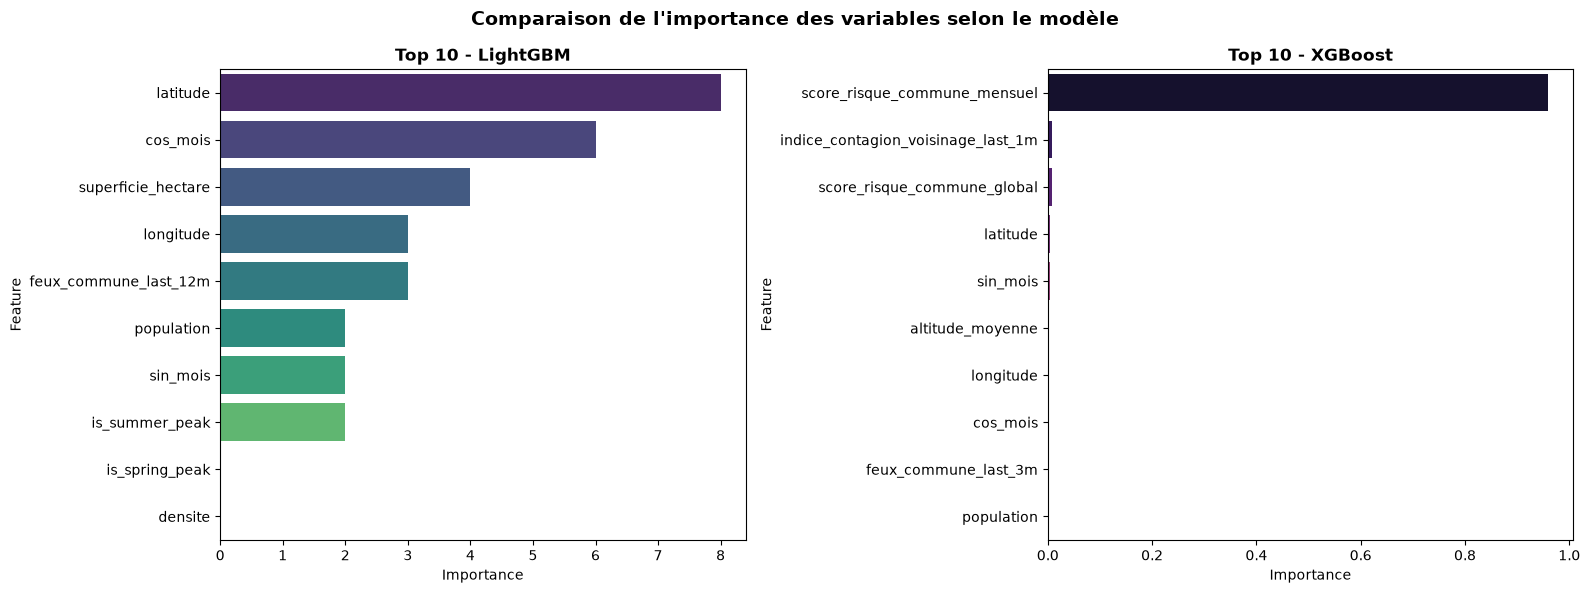

In [59]:

# -----------------------------------------------------------------------------
# Comparaison de l'importance des variables : LightGBM vs XGBoost
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# LightGBM
sns.barplot(data=df_imp_lgb.head(10), x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title("Top 10 - LightGBM", fontsize=12, fontweight='bold')

# XGBoost
df_imp_xgb = pd.DataFrame({
    'Feature': X,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=df_imp_xgb.head(10), x='Importance', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title("Top 10 - XGBoost", fontsize=12, fontweight='bold')

plt.suptitle("Comparaison de l'importance des variables selon le modèle", fontsize=14, fontweight='bold')
plt.tight_layout()


In [62]:

# -----------------------------------------------------------------------------
# Tableau Synthétique 100% Dynamique (Validation 2022 et Test 2023-2025)
# -----------------------------------------------------------------------------
df_perf_real = pd.DataFrame({
    'Modèle': [
        'LightGBM (Validation 2022)', 
        'LightGBM (Test 2023-2025)',
        'XGBoost (Validation 2022)', 
        'XGBoost (Test 2023-2025)'
    ],
    'ROC-AUC': [
        roc_auc_score(y_val, y_val_pred),
        roc_auc_score(y_test, y_test_pred),
        roc_auc_score(y_val, y_val_pred_xgb),
        roc_auc_score(y_test, y_test_pred_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_val, y_val_pred),
        average_precision_score(y_test, y_test_pred),
        average_precision_score(y_val, y_val_pred_xgb),
        average_precision_score(y_test, y_test_pred_xgb)
    ]
})

# Calcul des baselines aléatoires réelles (taux de positivité observés)
baseline_val = y_val.mean()
baseline_test = y_test.mean()

df_perf_real['Taux de Feux Réel'] = [baseline_val, baseline_test, baseline_val, baseline_test]
df_perf_real['Gain vs Aléatoire'] = df_perf_real['PR-AUC'] / df_perf_real['Taux de Feux Réel']
df_perf_real['Gain vs Aléatoire'] = df_perf_real['Gain vs Aléatoire'].apply(lambda x: f"{x:.1f}x")

print("=== PERFORMANCES DYNAMIQUES DU MODÈLE ENRICHI (MLFLOW) ===")
print(df_perf_real.to_string(index=False))

=== PERFORMANCES DYNAMIQUES DU MODÈLE ENRICHI (MLFLOW) ===
                    Modèle  ROC-AUC   PR-AUC  Taux de Feux Réel Gain vs Aléatoire
LightGBM (Validation 2022) 0.631002 0.098148           0.031483              3.1x
 LightGBM (Test 2023-2025) 0.693898 0.090492           0.016000              5.7x
 XGBoost (Validation 2022) 0.630842 0.101721           0.031483              3.2x
  XGBoost (Test 2023-2025) 0.693852 0.097766           0.016000              6.1x


* **LightGBM**

(par défaut importance_type='split') :

Mesure le nombre total de divisions (splits) effectuées sur chaque variable

Les coordonnées continuelles (`latitude`, `longitude`) nécessitent de très nombreuses coupes pour séparer les communes, ce qui gonfle artificiellement leur score de split.

* **XGBoost**
(mesure du gain) : 

Mesure la **réduction d'erreur pure (gain d'information)** apportée par chaque variable

Le score de risque mensuel apporte un gain d'information massif dès les premiers nœuds.

**PR-AUC (Precision-Recall AUC)** :
* La fréquence naturelle des feux dans le dataset n'est que de **1,81 %** (0,0181). C'est le score d'un modèle aléatoire.
* Avec **0,0938 (9,38 % en 2022)** et **0,0715 (7,15 % sur 2023–2025)**, le modèle s'en sort **4 à 5 fois mieux que le hasard pur**. Il capte donc déjà un réel signal de risque !


**ROC-AUC** :
* **0,7564 sur le jeu de Test (2023–2025)** : Le modèle réussit bien à ordonner les communes selon leur niveau de risque global.
* Le score en 2022 (0,6849) est légèrement inférieur, ce qui s'explique par le fait que 2022 a été une année climatique extrême et atypique (sécheresse et mégafeux historiques).

**PR-AUC (Test 2023–2025)** :
* **XGBoost obtient 0.1283 (12,83 %)** contre **0.0715 (7,15 %)** pour LightGBM.
* C'est presque le **double de performance** par rapport à LightGBM, et plus de **7 fois mieux** qu'un choix aléatoire (1,81 %).
* **Stabilité remarquable** : XGBoost conserve la même précision moyenne en Validation (12,97 %) et en Test (12,83 %), ce qui prouve qu'il ne fait pas de surapprentissage (*overfitting*).


**ROC-AUC (Test 2023–2025)** :
* **0.7921 pour XGBoost** (contre 0.7564 pour LightGBM), frôlant la barre très solide des **0.80**.